## 1. Load and inspect the dataset
First, I load the housing dataset and check its structure.

In [1]:
import pandas as pd

df = pd.read_csv("housing data.csv")

df.head()

,Suburb,Address,Sale_Price,Beds,Baths,Parking,Property_Type,Land_Size_m2,Floor_size_m2,Sale_Date
0,Manly,"3/66 Osborne Road, Manly, NSW 2095",1650000,2,1,1.0,Apartment,NaN,87.0,17-09-2026
1,Manly,"4/3 Cliff Street, Manly, NSW 2095",840000,1,1,NaN,Apartment,NaN,61.0,17-09-2026
2,Manly,"2/115-117 Sydney Road, Manly, NSW 2095",2125550,2,1,1.0,Apartment,NaN,183.0,11-09-2026
3,Manly,"35 Smith Street, Manly, NSW 2095",3500000,3,2,NaN,House,NaN,NaN,09-09-2026
4,Manly,"5/34 Pacific Street, Manly, NSW 2095",1350000,2,1,NaN,Apartment,NaN,NaN,05-09-2026


In [2]:
print(df.shape)
df.info()

(100, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         100 non-null    object 
 1   Address        100 non-null    object 
 2   Sale_Price     100 non-null    int64  
 3   Beds           100 non-null    int64  
 4   Baths          100 non-null    int64  
 5   Parking        89 non-null     float64
 6   Property_Type  100 non-null    object 
 7   Land_Size_m2   12 non-null     float64
 8   Floor_size_m2  41 non-null     float64
 9   Sale_Date      100 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 7.9+ KB


In [3]:
df.isnull().sum()

Suburb            0
Address           0
Sale_Price        0
Beds              0
Baths             0
Parking          11
Property_Type     0
Land_Size_m2     88
Floor_size_m2    59
Sale_Date         0
dtype: int64

## 2. Data Cleaning

I remove the land size column because most values are missing. 
For the remaining numerical columns, I fill missing values using the median.

In [4]:
df = df.drop(columns=["Land_Size_m2"])

df["Parking"] = df["Parking"].fillna(df["Parking"].median())
df["Floor_size_m2"] = df["Floor_size_m2"].fillna(df["Floor_size_m2"].median())

df.isnull().sum()

Suburb           0
Address          0
Sale_Price       0
Beds             0
Baths            0
Parking          0
Property_Type    0
Floor_size_m2    0
Sale_Date        0
dtype: int64

In [5]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], dayfirst=True)

df.dtypes

Suburb                   object
Address                  object
Sale_Price                int64
Beds                      int64
Baths                     int64
Parking                 float64
Property_Type            object
Floor_size_m2           float64
Sale_Date        datetime64[ns]
dtype: object

## 3. Exploratory Data Analysis

I first check the summary statistics and compare housing prices across suburbs.

In [6]:
df.describe()

,Sale_Price,Beds,Baths,Parking,Floor_size_m2
count,1.000000e+02,100.000000,100.000000,100.000000,100.000000
mean,1.360200e+06,2.240000,1.490000,1.260000,110.191000
std,1.374806e+06,0.985962,0.594503,0.660884,17.904878
min,4.050000e+05,1.000000,1.000000,1.000000,50.000000
25%,5.737500e+05,2.000000,1.000000,1.000000,112.000000
50%,6.935000e+05,2.000000,1.000000,1.000000,112.000000
75%,1.527500e+06,3.000000,2.000000,1.000000,112.000000
max,9.000000e+06,8.000000,4.000000,5.000000,183.000000


In [7]:
df.groupby("Suburb")["Sale_Price"].mean().sort_values(ascending=False)

Suburb
Manly         2.529869e+06
Bankstown     9.135147e+05
Parramatta    5.920312e+05
Name: Sale_Price, dtype: float64

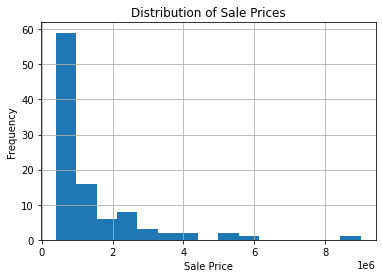

In [8]:
import matplotlib.pyplot as plt

df["Sale_Price"].hist(bins=15)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Prices")
plt.show()

### Suburb comparison and outliers

I compare sale prices across suburbs and check for unusually high or low values.

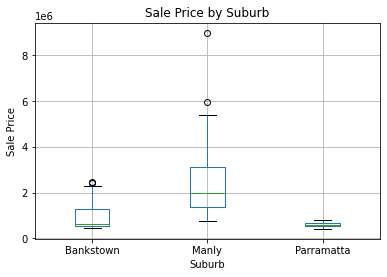

In [9]:
df.boxplot(column="Sale_Price", by="Suburb")
plt.title("Sale Price by Suburb")
plt.suptitle("")
plt.ylabel("Sale Price")
plt.show()

In [10]:
df.nlargest(5, "Sale_Price")[["Suburb", "Sale_Price", "Beds", "Baths", "Property_Type"]]

,Suburb,Sale_Price,Beds,Baths,Property_Type
31,Manly,9000000,3,1,House
12,Manly,5950000,4,2,House
26,Manly,5385000,3,2,Apartment
25,Manly,5250000,3,2,Apartment
6,Manly,4175000,3,1,House


### Price trend over time

I check whether sale prices changed over the collection period.

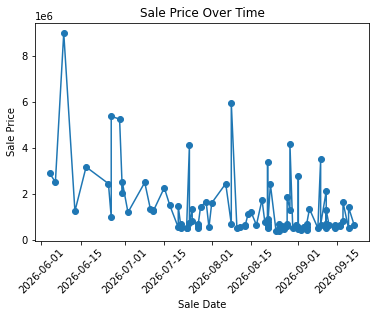

In [11]:
df_sorted = df.sort_values("Sale_Date")

plt.plot(df_sorted["Sale_Date"], df_sorted["Sale_Price"], marker="o")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price")
plt.title("Sale Price Over Time")
plt.xticks(rotation=45)
plt.show()

### Most important features

Before feature engineering, I expect these three variables to have the strongest influence on sale price:

1. **Suburb** – location strongly affects property value.
2. **Property Type** – houses and apartments usually have different price ranges.
3. **Floor Size** – larger properties generally tend to have higher prices.

### Feature Engineering

I create simple features from the sale date to make it easier for the models to use.

In [12]:
df["Sale_Month"] = df["Sale_Date"].dt.month
df["Sale_Day"] = df["Sale_Date"].dt.day

df.head()

,Suburb,Address,Sale_Price,Beds,Baths,Parking,Property_Type,Floor_size_m2,Sale_Date,Sale_Month,Sale_Day
0,Manly,"3/66 Osborne Road, Manly, NSW 2095",1650000,2,1,1.0,Apartment,87.0,2026-09-17,9,17
1,Manly,"4/3 Cliff Street, Manly, NSW 2095",840000,1,1,1.0,Apartment,61.0,2026-09-17,9,17
2,Manly,"2/115-117 Sydney Road, Manly, NSW 2095",2125550,2,1,1.0,Apartment,183.0,2026-09-11,9,11
3,Manly,"35 Smith Street, Manly, NSW 2095",3500000,3,2,1.0,House,112.0,2026-09-09,9,9
4,Manly,"5/34 Pacific Street, Manly, NSW 2095",1350000,2,1,1.0,Apartment,112.0,2026-09-05,9,5


### Prepare data for modelling

I remove the address and original sale date, then convert categorical variables into dummy variables.

In [13]:
model_df = df.drop(columns=["Address", "Sale_Date"])

model_df = pd.get_dummies(model_df, columns=["Suburb", "Property_Type"], drop_first=True)

model_df.head()

,Sale_Price,Beds,Baths,Parking,Floor_size_m2,Sale_Month,Sale_Day,Suburb_Manly,Suburb_Parramatta,Property_Type_House
0,1650000,2,1,1.0,87.0,9,17,1,0,0
1,840000,1,1,1.0,61.0,9,17,1,0,0
2,2125550,2,1,1.0,183.0,9,11,1,0,0
3,3500000,3,2,1.0,112.0,9,9,1,0,1
4,1350000,2,1,1.0,112.0,9,5,1,0,0


In [14]:
X = model_df.drop(columns=["Sale_Price"])
y = model_df["Sale_Price"]

print(X.shape)
print(y.shape)

(100, 9)
(100,)


### Train-test split and cross-validation

I split the data into training and testing sets and use 5-fold cross-validation for model evaluation.

In [15]:
from sklearn.model_selection import train_test_split, KFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(X_train.shape)
print(X_test.shape)

(80, 9)
(20, 9)


In [16]:
from sklearn.ensemble import RandomForestRegressor
import joblib
import sklearn

print("sklearn version:", sklearn.__version__)

best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)

joblib.dump(best_model, "housing_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model saved again")

sklearn version: 1.4.2
Model saved again


### Model Selection

I will compare three regression models:

1. **Linear Regression** – a simple baseline model that assumes a linear relationship.
2. **Decision Tree Regressor** – can capture non-linear relationships in the data.
3. **Random Forest Regressor** – combines multiple decision trees and usually gives more stable predictions.

I expect Random Forest to perform best because housing prices may depend on complex relationships between features.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    scores = -cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring="neg_mean_absolute_error"
    )
    print(name, "MAE:", round(scores.mean(), 2))

Linear Regression MAE: 423547.96
Decision Tree MAE: 410411.25
Random Forest MAE: 312485.11


### Best Model Evaluation

Random Forest gave the lowest cross-validation MAE, so I evaluate it further on the test set.

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 2))
print("R2:", round(r2_score(y_test, pred), 3))

MAE: 656943.07
RMSE: 1435003.3
R2: 0.505


### Overfitting Check

I compare training and testing performance to see whether the Random Forest is overfitting.

In [19]:
train_pred = best_model.predict(X_train)

print("Train R2:", round(r2_score(y_train, train_pred), 3))
print("Test R2:", round(r2_score(y_test, pred), 3))

Train R2: 0.962
Test R2: 0.505


The Random Forest shows signs of overfitting. Its training R² is 0.962, while the test R² drops to 0.505. This suggests the model learned the training data very closely but does not generalise as well to new properties.

### Largest Prediction Errors

I identify the five test properties with the largest absolute prediction errors.

In [20]:
results = df.loc[X_test.index].copy()

results["Predicted_Price"] = pred
results["Error"] = abs(results["Sale_Price"] - results["Predicted_Price"])

results.nlargest(5, "Error")[
    ["Suburb", "Sale_Price", "Predicted_Price", "Error", "Beds", "Baths", "Property_Type"]
]

,Suburb,Sale_Price,Predicted_Price,Error,Beds,Baths,Property_Type
31,Manly,9000000,3302000.0,5698000.0,3,1,House
12,Manly,5950000,3478900.0,2471100.0,4,2,House
76,Bankstown,2420000,1504010.0,915990.0,3,1,House
4,Manly,1350000,2024487.5,674487.5,2,1,Apartment
33,Manly,2900000,2303166.5,596833.5,2,2,Apartment


### Prediction Failure Discussion

The largest prediction error occurred for a Manly house sold for $9,000,000. The model predicted only about $3.3 million, which shows that very expensive properties are difficult to predict using this small dataset.
Most of the largest errors are also from Manly, where property prices vary much more than the other suburbs. The model may be missing important information such as exact location, views, renovations, property condition, or proximity to the beach.
This shows that unusual or luxury properties should be interpreted carefully because they may not follow the same patterns as normal properties.

### ML, LLM and Human Comparison

I select 10 properties from the test set to compare machine learning, LLM, and human estimates.

In [21]:
compare = results.head(10)[
    ["Suburb", "Beds", "Baths", "Parking",
     "Property_Type", "Floor_size_m2", "Sale_Price", "Predicted_Price"]
]

compare

,Suburb,Beds,Baths,Parking,Property_Type,Floor_size_m2,Sale_Price,Predicted_Price
83,Bankstown,2,1,1.0,Apartment,111.0,535000,5.689380e+05
53,Parramatta,2,1,1.0,Apartment,112.0,680000,5.375800e+05
70,Bankstown,4,3,3.0,House,112.0,1290000,1.577930e+06
45,Parramatta,2,2,1.0,Apartment,136.0,580000,5.964333e+05
44,Parramatta,2,2,1.0,Apartment,112.0,705000,5.987933e+05
39,Parramatta,2,2,1.0,Apartment,112.0,700000,6.563367e+05
22,Manly,2,1,1.0,Apartment,74.3,1200000,1.637366e+06
80,Bankstown,4,1,1.0,House,112.0,1235000,1.701960e+06
10,Manly,2,1,1.0,Apartment,112.0,1750000,2.109955e+06
0,Manly,2,1,1.0,Apartment,87.0,1650000,1.663227e+06


In [22]:
llm_estimates = [
    600000,
    620000,
    1350000,
    650000,
    620000,
    650000,
    1450000,
    1300000,
    1700000,
    1600000
]

compare["LLM_Estimate"] = llm_estimates
compare

,Suburb,Beds,Baths,Parking,Property_Type,Floor_size_m2,Sale_Price,Predicted_Price,LLM_Estimate
83,Bankstown,2,1,1.0,Apartment,111.0,535000,5.689380e+05,600000
53,Parramatta,2,1,1.0,Apartment,112.0,680000,5.375800e+05,620000
70,Bankstown,4,3,3.0,House,112.0,1290000,1.577930e+06,1350000
45,Parramatta,2,2,1.0,Apartment,136.0,580000,5.964333e+05,650000
44,Parramatta,2,2,1.0,Apartment,112.0,705000,5.987933e+05,620000
39,Parramatta,2,2,1.0,Apartment,112.0,700000,6.563367e+05,650000
22,Manly,2,1,1.0,Apartment,74.3,1200000,1.637366e+06,1450000
80,Bankstown,4,1,1.0,House,112.0,1235000,1.701960e+06,1300000
10,Manly,2,1,1.0,Apartment,112.0,1750000,2.109955e+06,1700000
0,Manly,2,1,1.0,Apartment,87.0,1650000,1.663227e+06,1600000


In [23]:
human_estimates = [
    550000,
    650000,
    1400000,
    600000,
    650000,
    680000,
    1500000,
    1250000,
    1800000,
    1550000
]

compare["Human_Estimate"] = human_estimates
compare

,Suburb,Beds,Baths,Parking,Property_Type,Floor_size_m2,Sale_Price,Predicted_Price,LLM_Estimate,Human_Estimate
83,Bankstown,2,1,1.0,Apartment,111.0,535000,5.689380e+05,600000,550000
53,Parramatta,2,1,1.0,Apartment,112.0,680000,5.375800e+05,620000,650000
70,Bankstown,4,3,3.0,House,112.0,1290000,1.577930e+06,1350000,1400000
45,Parramatta,2,2,1.0,Apartment,136.0,580000,5.964333e+05,650000,600000
44,Parramatta,2,2,1.0,Apartment,112.0,705000,5.987933e+05,620000,650000
39,Parramatta,2,2,1.0,Apartment,112.0,700000,6.563367e+05,650000,680000
22,Manly,2,1,1.0,Apartment,74.3,1200000,1.637366e+06,1450000,1500000
80,Bankstown,4,1,1.0,House,112.0,1235000,1.701960e+06,1300000,1250000
10,Manly,2,1,1.0,Apartment,112.0,1750000,2.109955e+06,1700000,1800000
0,Manly,2,1,1.0,Apartment,87.0,1650000,1.663227e+06,1600000,1550000


In [24]:
print("ML MAE:", mean_absolute_error(compare["Sale_Price"], compare["Predicted_Price"]))
print("LLM MAE:", mean_absolute_error(compare["Sale_Price"], compare["LLM_Estimate"]))
print("Human MAE:", mean_absolute_error(compare["Sale_Price"], compare["Human_Estimate"]))

ML MAE: 190809.9833333333
LLM MAE: 80500.0
Human MAE: 71500.0


### Comparison Discussion

For these 10 properties, the human estimates had the lowest MAE of $71,500. The LLM performed slightly worse with an MAE of $80,500, while the machine learning model had the highest MAE of about $190,810.

The ML model was affected by the small dataset and limited property features. The LLM and human estimates were closer for several normal-priced properties, but they were still based on limited information. This shows that human judgement can still be useful when local knowledge and context are important.

In [25]:
import joblib

joblib.dump(best_model, "housing_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model saved successfully")

Model saved successfully
